# Rossmann Store Sales — Feature Engineering & Baseline Model

**Goal:** Build time-aware features, set up a chronological train/validation/test split, and
establish a naive baseline forecast to compare later models against.

Sections:
1. Load and clean data
2. Calendar features
3. Lag and rolling features (per store)
4. Chronological train/validation/test split
5. Naive baselines
6. Evaluation metrics (RMSE, MAE, RMSPE)
7. Key takeaways

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 1. Load and Clean Data

Same loading/merging/cleaning steps as notebook 01, repeated here so this notebook can run
independently.

In [2]:
train = pd.read_csv('../data/train.csv', parse_dates=['Date'], low_memory=False)
store = pd.read_csv('../data/store.csv')

df = train.merge(store, on='Store', how='left')
df = df[df['Open'] == 1].copy()
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

print(df.shape)
print('Date range:', df['Date'].min(), 'to', df['Date'].max())

(844392, 18)
Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00


## 2. Calendar Features

Simple date-derived features. Cheap to compute and often surprisingly predictive.

In [3]:
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0 = Monday
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

df[['Date', 'DayOfWeek', 'Month', 'Year', 'WeekOfYear', 'IsWeekend']].head()

,Date,DayOfWeek,Month,Year,WeekOfYear,IsWeekend
0,2013-01-02,2,1,2013,1,0
1,2013-01-03,3,1,2013,1,0
2,2013-01-04,4,1,2013,1,0
3,2013-01-05,5,1,2013,1,1
4,2013-01-07,0,1,2013,2,0


## 3. Lag and Rolling Features (Per Store)

**Important:** these must be computed *within each store* (using `groupby('Store')`), never
across the whole dataset at once — otherwise you'd be mixing one store's history into another
store's features, which makes no sense and quietly corrupts your model.

In [4]:
# Lag features: sales N days ago, per store
for lag in [1, 7, 14]:
    df[f'Sales_lag_{lag}'] = df.groupby('Store')['Sales'].shift(lag)

# Rolling averages: trailing 7-day and 30-day average, per store
# .shift(1) first so the rolling window doesn't include the current day (that would leak the target)
for window in [7, 30]:
    df[f'Sales_rollmean_{window}'] = (
        df.groupby('Store')['Sales']
          .transform(lambda s: s.shift(1).rolling(window).mean())
    )

df[['Store', 'Date', 'Sales', 'Sales_lag_1', 'Sales_lag_7', 'Sales_rollmean_7', 'Sales_rollmean_30']].head(10)

,Store,Date,Sales,Sales_lag_1,Sales_lag_7,Sales_rollmean_7,Sales_rollmean_30
0,1,2013-01-02,5530,NaN,NaN,NaN,NaN
1,1,2013-01-03,4327,5530.0,NaN,NaN,NaN
2,1,2013-01-04,4486,4327.0,NaN,NaN,NaN
3,1,2013-01-05,4997,4486.0,NaN,NaN,NaN
4,1,2013-01-07,7176,4997.0,NaN,NaN,NaN
5,1,2013-01-08,5580,7176.0,NaN,NaN,NaN
6,1,2013-01-09,5471,5580.0,NaN,NaN,NaN
7,1,2013-01-10,4892,5471.0,5530.0,5366.714286,NaN
8,1,2013-01-11,4881,4892.0,4327.0,5275.571429,NaN
9,1,2013-01-12,4952,4881.0,4486.0,5354.714286,NaN


In [5]:
# These features are NaN for the first N days of each store's history (no prior data yet).
# Drop those rows rather than filling them, since filling would fabricate history that doesn't exist.
before = len(df)
df = df.dropna(subset=['Sales_lag_14', 'Sales_rollmean_30']).reset_index(drop=True)
print(f'Dropped {before - len(df)} rows with insufficient history ({(before - len(df)) / before:.1%})')

Dropped 33450 rows with insufficient history (4.0%)


## 4. Chronological Train/Validation/Test Split

Unlike the diabetes project, we CANNOT randomly shuffle rows here. A random split would let
the model 'see the future' (e.g. train on a Tuesday in March and test on the previous Monday),
which inflates performance in a way that won't hold up on genuinely new data.

Instead, split by date: train on the earliest period, validate on the next chunk, test on the
most recent period -- mirroring how the model would actually be used (forecasting the future
from the past).

In [6]:
print('Full date range:', df['Date'].min(), 'to', df['Date'].max())

# Roughly: train on everything before the last ~10 weeks, validate on the next ~6 weeks,
# test on the final ~4 weeks. Adjust these cutoffs based on your actual date range.
train_cutoff = pd.Timestamp('2015-05-14')
valid_cutoff = pd.Timestamp('2015-06-25')

train_df = df[df['Date'] <= train_cutoff]
valid_df = df[(df['Date'] > train_cutoff) & (df['Date'] <= valid_cutoff)]
test_df = df[df['Date'] > valid_cutoff]

print('Train:', train_df.shape, train_df['Date'].min(), '-', train_df['Date'].max())
print('Valid:', valid_df.shape, valid_df['Date'].min(), '-', valid_df['Date'].max())
print('Test: ', test_df.shape, test_df['Date'].min(), '-', test_df['Date'].max())

Full date range: 2013-01-31 00:00:00 to 2015-07-31 00:00:00
Train: (737707, 27) 2013-01-31 00:00:00 - 2015-05-14 00:00:00
Valid: (38555, 27) 2015-05-15 00:00:00 - 2015-06-25 00:00:00
Test:  (34680, 27) 2015-06-26 00:00:00 - 2015-07-31 00:00:00


## 5. Naive Baselines

Before any real model, establish what a trivial forecast achieves. Two common naive baselines:
- **Same day last week**: predict this Monday's sales = last Monday's sales
- **7-day rolling average**: predict using the trailing 7-day average

If a sophisticated model can't beat these, it's not adding value.

In [7]:
# 'Same day last week' baseline is literally the Sales_lag_7 feature we already built
valid_df = valid_df.copy()
valid_df['pred_naive_lastweek'] = valid_df['Sales_lag_7']
valid_df['pred_naive_rollmean7'] = valid_df['Sales_rollmean_7']

valid_df[['Store', 'Date', 'Sales', 'pred_naive_lastweek', 'pred_naive_rollmean7']].head(10)

,Store,Date,Sales,pred_naive_lastweek,pred_naive_rollmean7
686,1,2015-05-15,4178,4960.0,4316.142857
687,1,2015-05-16,4431,4529.0,4204.428571
688,1,2015-05-18,5280,4683.0,4190.428571
689,1,2015-05-19,5235,4945.0,4275.714286
690,1,2015-05-20,4735,3551.0,4317.142857
691,1,2015-05-21,3755,3547.0,4486.285714
692,1,2015-05-22,4459,3998.0,4516.000000
693,1,2015-05-23,4276,4178.0,4581.857143
694,1,2015-05-26,4211,4431.0,4595.857143
695,1,2015-05-27,4083,5280.0,4564.428571


## 6. Evaluation Metrics

- **RMSE**: root mean squared error, in the same units as Sales (interpretable in dollars/sales)
- **MAE**: mean absolute error, less sensitive to outliers than RMSE
- **RMSPE**: root mean squared PERCENTAGE error — the original Kaggle competition metric, and
  the easiest to explain to a non-technical audience as 'average % off'

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def rmspe(y_true, y_pred):
    """Root Mean Squared Percentage Error, ignoring rows where actual sales are 0
    (can't compute a meaningful % error against zero)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.sqrt(np.mean(((y_true[mask] - y_pred[mask]) / y_true[mask]) ** 2))


def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    rmspe_val = rmspe(y_true, y_pred)
    print(f'{name}: RMSE={rmse:.1f}  MAE={mae:.1f}  RMSPE={rmspe_val:.3f}')
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'RMSPE': rmspe_val}


results = []
results.append(evaluate('Naive: same day last week', valid_df['Sales'], valid_df['pred_naive_lastweek']))
results.append(evaluate('Naive: 7-day rolling avg', valid_df['Sales'], valid_df['pred_naive_rollmean7']))

results_df = pd.DataFrame(results).set_index('Model')
results_df

Naive: same day last week: RMSE=2758.8  MAE=2155.1  RMSPE=0.455
Naive: 7-day rolling avg: RMSE=2003.9  MAE=1482.8  RMSPE=0.337


,RMSE,MAE,RMSPE
Model,,,
Naive: same day last week,2758.793658,2155.069252,0.455362
Naive: 7-day rolling avg,2003.892386,1482.780047,0.336867


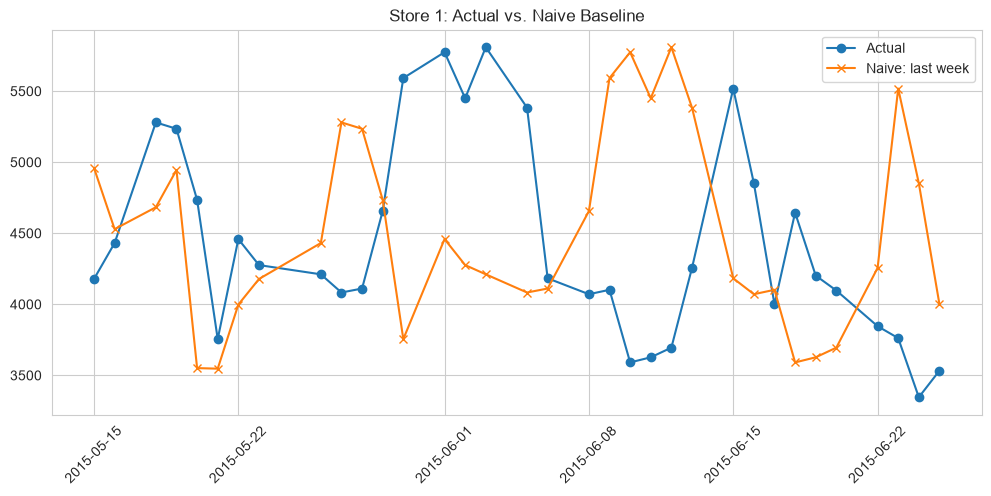

In [9]:
# Visualize actual vs. predicted for one store, to sanity check the naive baseline
sample_store = valid_df['Store'].iloc[0]
sample = valid_df[valid_df['Store'] == sample_store].sort_values('Date')

plt.plot(sample['Date'], sample['Sales'], label='Actual', marker='o')
plt.plot(sample['Date'], sample['pred_naive_lastweek'], label='Naive: last week', marker='x')
plt.title(f'Store {sample_store}: Actual vs. Naive Baseline')
plt.legend()
plt.xticks(rotation=45)
plt.show()